<a href="https://colab.research.google.com/github/Luke-Zingg/CitiBike-Year-by-Year-Comparison/blob/main/CitiBike_SQL/Python_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Citi Bike Year-over-Year Ridership Analysis

Citi Bike is one of the largest bike-sharing platforms in the United States, providing riders throughout New York City an alternative form of transportation. As with many mobility services, understanding changes in customer demand is vital for operational planning. Trends in ridership give a glimpse into the health of the company and wise next steps.

In this project, I analyze publicly available Citi Bike data exclusively from the first quarter (January through March) of 2025 and 2026. This period is of special interest in part because of it's recency, and also because the company saw a significant decrease of rides in 2026 as compared to the previous year. The dataset I use contains each ride taken during the study period, and includes the ride start time and end time, bicycle type, and station locations. Using Python and SQL, I investigate these datasets to discover how ridership patterns changed between the two years.

It is worth noting that the code for this project was designed to be easily reusable for future analyses. The data is stored in GitHub and accessed directly through raw file links, allowing the analysis to be rerun with minimal modification. By simply changing the data source in the initial section of the code, the entire workflow will execute  using the new data. As a result, this program can readily be used to compare performance across future periods, such as Q2 or Q3.

The primary goal of the analysis is to determine whether changes in rider dermand were concentrated within specific rider categories or whether the observed decline was broadly distributed across the Citi Bike network. To do this, I examine several dimensions of the data, including weekday versus weekend usage, time-of-day riding patterns, and station-level demand.

# Analysis

We begin by importing the necessary libraries and our data from GitHub. We then combine the monthly ride data from 2025 and 2026 into a single dataframe, as well as create a few new columns for our analysis.

In [2]:
# Install libraries and import raw data

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

# Load Q1 Citi Bike data for 2025 and 2026

Jan_25 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202501-citibike-tripdata.csv"
Feb_25 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202502-citibike-tripdata.csv"
Mar_25 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202503-citibike-tripdata.csv"

Jan_26 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202601-citibike-tripdata.csv"
Feb_26 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202602-citibike-tripdata.csv"
Mar_26 = "https://raw.githubusercontent.com/Luke-Zingg/CitiBike-Year-by-Year-Comparison/refs/heads/main/JC-202603-citibike-tripdata.csv"

files = [
    (Jan_25, 2025, "January"),
    (Feb_25, 2025, "February"),
    (Mar_25, 2025, "March"),
    (Jan_26, 2026, "January"),
    (Feb_26, 2026, "February"),
    (Mar_26, 2026, "March"),
]

dataframes = []

for url, year, month in files:
    df = pd.read_csv(url)
    df["year"] = year
    df["month"] = month
    dataframes.append(df)

all_rides = pd.concat(dataframes, ignore_index=True)

#Make the started_at and ended_at category datetimes, so we can
#see if change in demand can be tracked to certain days of the week.
all_rides["started_at"] = pd.to_datetime(all_rides["started_at"])
all_rides["ended_at"] = pd.to_datetime(all_rides["ended_at"])

#Gives day of the week for each ride by start time
all_rides["day_of_week"] = all_rides["started_at"].dt.day_name()

#Gives Weekday or Weekend categories
all_rides["day_type"] = all_rides["day_of_week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

#Finds hour (0 - 24) that the ride started at
all_rides["hour"] = all_rides["started_at"].dt.hour

#Defines the time of day the ride started at
def classify_time_period(hour):
    if 6 <= hour <= 10:
        return "Morning"
    elif 11 <= hour <= 15:
        return "Midday"
    elif 16 <= hour <= 19:
        return "Evening"
    else:
        return "Night"

all_rides["time_period"] = (
    all_rides["hour"]
    .apply(classify_time_period)
)


# Creates a temporary database in RAM
conn = sqlite3.connect(":memory:")

# Creates a SQL table called all_rides
# if_exists="replace" means that if the table already exists, it gets overwritten
all_rides.to_sql("all_rides", conn, if_exists="replace", index=False)

297379

With our data put together, a strong starting point is to examine the overall change in ridership between the two years. It is important to first understand the scale of the change we are attempting to explain. We do so below and observe a stark 24.2% decrease in ridership from 2025 to 2026. Such a substantial decline suggests that the underlying cause is implausible to prescribe to random chance and instead points toward broader factors affecting rider demand. The remainder of this analysis aims to determine whether this decrease can be explained by particular groups of rides or whether it reflects a more general shift in ridership patterns.

In [4]:
#Looks at the total number of rides between years

total_by_year_query = """
SELECT year, COUNT(*) AS total_rides
FROM all_rides
GROUP BY year
ORDER BY year;
"""

pd.read_sql(total_by_year_query, conn)

total_by_year = pd.read_sql(total_by_year_query, conn)

total_by_year["pct_change"] = (
    total_by_year["total_rides"]
    .pct_change()
    * 100
).round(1).fillna("")

total_by_year

,year,total_rides,pct_change
0,2025,169159,
1,2026,128220,-24.2


To dig one step deeper, we will next see how the number of rides varied in both years from month to month.

In [43]:
#Looks at the total number of rides between years

total_by_month_query = """
SELECT month, year, COUNT(*) AS total_rides
FROM all_rides
GROUP BY year, month
ORDER BY
    CASE month
        WHEN 'January' THEN 1
        WHEN 'February' THEN 2
        WHEN 'March' THEN 3
    END;
"""

monthly_counts = pd.read_sql(total_by_month_query, conn)

monthly_comparison = monthly_counts.pivot(
    index="month",
    columns="year",
    values="total_rides"
)

monthly_comparison = monthly_comparison.reindex(
    ["January", "February", "March"]
)

monthly_comparison["pct_change"] = round(
    (monthly_comparison[2026] - monthly_comparison[2025])/monthly_comparison[2025]*100,1)

monthly_comparison

year,2025,2026,pct_change
month,,,
January,50611,40044,-20.9
February,45255,25809,-43.0
March,73293,62367,-14.9


We notice the largest drop in ridership in the month of February, with a 43% decrease in rides from 2025 to 2026. This drastic decrease may point towards a potential explanation for the decrease in demand: weather. Weather data suggests that February 2026 was noticably colder and snowier than February 2025, which would offer a reasonable explanation for the lack of demand for bike rentals.

[Weather Spark](https://https://weatherspark.com/h/m/23912/2026/2/Historical-Weather-in-February-2026-in-New-York-City-New-York-United-States#Figures-Temperature) data suggests that February 2026 generally had  harsher weather conditions in the month of February than 2025.

Though weather does appear to be reasonable factor for the significant decrease in CitiBike demand for the first quarter of 2026, we will continue to comb through the data to see if there are any other noteable changes in demand patterns between the years.

Another possible explanation for the decline in ridership is a reduction in either commuting or recreational use of the platform. One simple way to investigate this is to compare weekday and weekend ridership between 2025 and 2026. The figure below plots the total number of weekday and weekend rides for each year and displays the corresponding percent change in ridership.

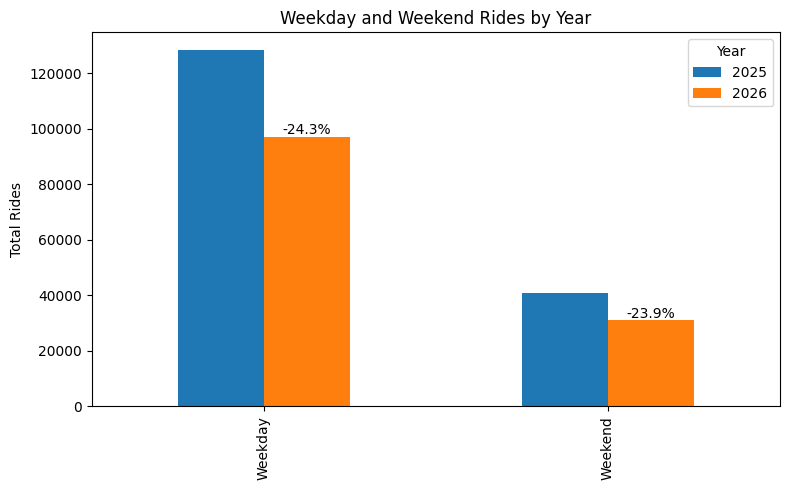

In [11]:
day_type_query = """
SELECT year, day_type, COUNT(*) AS total_rides
FROM all_rides
GROUP BY year, day_type
ORDER BY year;
"""

day_type_counts = pd.read_sql(day_type_query, conn)

#pivot so we do percentage chance comparison
day_type_plot = day_type_counts.pivot(
    index="day_type",
    columns="year",
    values="total_rides"
).reindex(["Weekday", "Weekend"])

day_type_plot["pct_change"] = (
    (day_type_plot[2026] - day_type_plot[2025])
    / day_type_plot[2025]
    * 100
).round(1)

#Begin constructing plot
ax = day_type_plot[[2025, 2026]].plot(
    kind="bar",
    figsize=(8, 5)
)

#Aesthetics
plt.title("Weekday and Weekend Rides by Year")
plt.xlabel("")
plt.ylabel("Total Rides")
plt.legend(title="Year")

#Creates bars (I miss ggplot already)
weekday_height = day_type_plot.loc["Weekday", 2026]
weekday_change = day_type_plot.loc["Weekday", "pct_change"]

weekend_height = day_type_plot.loc["Weekend", 2026]
weekend_change = day_type_plot.loc["Weekend", "pct_change"]

#Create x-axis text
ax.text(
    0.125,
    weekday_height + 1000,
    f"{weekday_change}%",
    ha="center"
)

ax.text(
    1.125,
    weekend_height + 1000,
    f"{weekend_change}%",
    ha="center"
)

plt.tight_layout()
plt.show()

Weekday and weekend ridership fell by very similar amounts, decreasing by 24.3% and 23.9% respectively. If the overall decline in Citi Bike demand were primarily driven by changes in commuting or recreational usage, we would expect one category to experience a substantially larger decrease than the other. Instead the nearly identical declines suggest the reduction in ridership was distributed evenly across both weekday and weekend riders, providing little evidence that shifts in  commuting or leisure activity were a significant driver of the observed decline.

To further study whether the decline in ridership can be attributed to a weekly pattern, we examine the distribution of rides across each day of the week in 2025 and 2026. The figure below shows the percentage of total rides occurring on each day, allowing us to compare how the weekly composition of ridership changed between years.

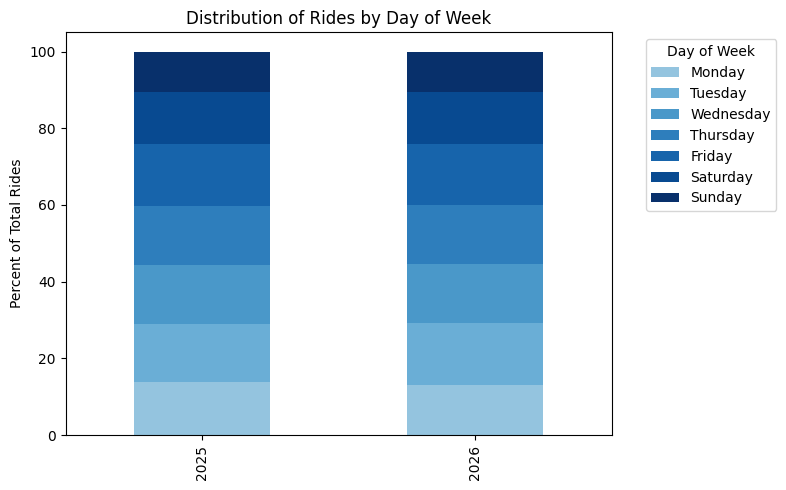

In [15]:
day_of_week_query = """
SELECT year, day_of_week, COUNT(*) AS total_rides
FROM all_rides
GROUP BY year, day_of_week;
"""

day_of_week_counts = pd.read_sql(day_of_week_query, conn)

day_of_week_counts["pct_by_year"] = (
    day_of_week_counts["total_rides"]
    / day_of_week_counts.groupby("year")["total_rides"].transform("sum")
    * 100
).round(3)

#Pivot for plot
day_of_week_stacked = day_of_week_counts.pivot(
    index="year",
    columns="day_of_week",
    values="pct_by_year"
)

#Ensure order is not alphabetical
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_of_week_stacked = day_of_week_stacked[day_order]

#Create a blue color scheme for plot
blue_pallette = plt.cm.Blues(np.linspace(0.4, 1, 7))


#Generate plot
ax = day_of_week_stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=blue_pallette
)
plt.title("Distribution of Rides by Day of Week")
plt.xlabel("")
plt.ylabel("Percent of Total Rides")
plt.legend(
    title="Day of Week",
    #Keeps legend outside of plot
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

We notice that the 2025 and 2026 bars look nearly identical, demonstrating that there were no major fluctuations in the distribution of rides by day of the week. In other words, the 24.2% decrease in total rides in 2026 was felt almost uniformly across the week rather than being concentrated on specific days. This suggests that the decline was not driven by changes in a particular weekly activity pattern, such as reduced start-of-week commuting that may come with a more remote-heavy work life. Instead, ridership appears to have decreased broadly regardless of the day.

While the day-of-the-week composition was largely unchanged, riders may still have altered when they use CitiBike within a given day. Examining ridership by time of day allows us to consider whether the decline was concentrated during traditional commuting hours, midday travel, or nighttime usage, providing greater insight into the behavioral changes.

As an initial first-glance-comparison, we will plot histograms for the distribution of ride start times by the hour for both years. This will give us an initial guage for if the times at which people took rides changed noticably from 2025 to 2026.

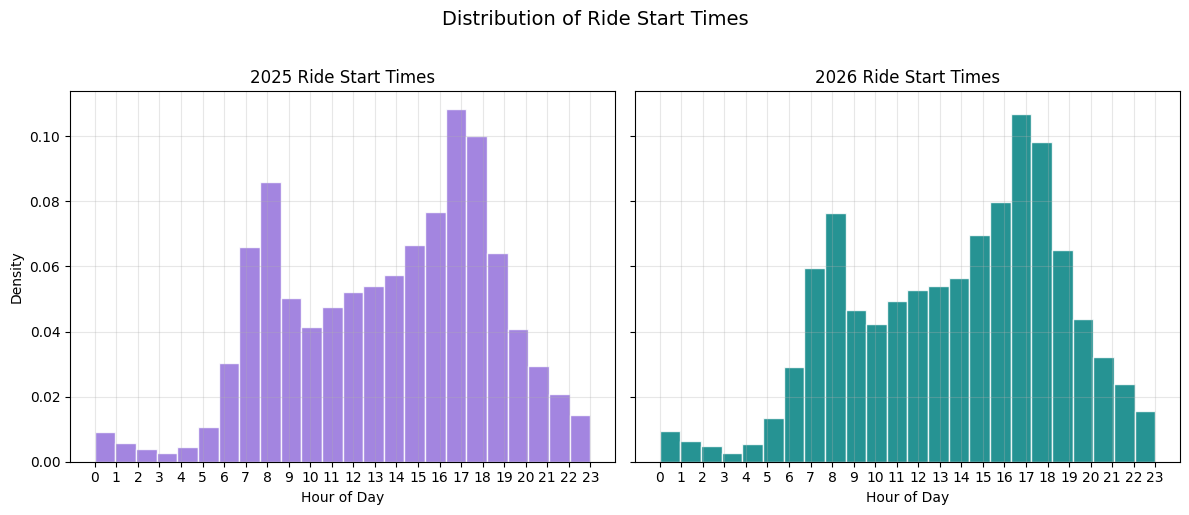

In [19]:
#I respect Python, but this doesn't hold a candle to the elegance of R's ggplot!
#I'm doing my best to mimic ggplot vibes here.

#Initialize plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    sharey=True
)

# 2025 rides
all_rides[all_rides["year"] == 2025]["hour"].plot(
    kind="hist",
    bins=24,
    density=True,
    color="mediumpurple",
    edgecolor="white",
    alpha=0.85,
    ax=axes[0]
)

axes[0].set_title("2025 Ride Start Times")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Density")
axes[0].set_xticks(range(0, 24, 1))
axes[0].grid(alpha=0.3)

# 2026
all_rides[all_rides["year"] == 2026]["hour"].plot(
    kind="hist",
    bins=24,
    density=True,
    color="teal",
    edgecolor="white",
    alpha=0.85,
    ax=axes[1]
)

axes[1].set_title("2026 Ride Start Times")
axes[1].set_xlabel("Hour of Day")
axes[1].set_xticks(range(0, 24, 1))
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Distribution of Ride Start Times",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

We notice a strong similarity between both histograms, suggesting that time-of-day did not substantially change in 2026. As a second, less visual check, we will break up the day into four time groups: Morning (6 AM - 10 AM), Midday (11 AM - 3 PM), Evening (4 PM - 7 PM), and Night (8 PM - 5 AM). Though these groupings are somewhat arbitrary, they act as a reasonable bins for understanding change in demand over the time of day. Notice that the Morning and Evening timeframes capture the spikes or humps we see within our histograms, no doubt due to an uptake in ridership for work commutes.

The table below summarizes ridership across each time-of-day category, including the total number of rides in 2025 and 2026 as well as the corresponding percentage decrease.

In [23]:
#Create query for total rides by each period

time_period_query = """
SELECT year, time_period, COUNT(*) AS total_rides
FROM all_rides
GROUP BY year, time_period
ORDER BY year;
"""

time_period_counts = pd.read_sql(
    time_period_query,
    conn
)

time_period_counts["pct_by_year"] = (
    time_period_counts["total_rides"]
    / time_period_counts.groupby("year")["total_rides"].transform("sum")
    * 100
).round(3)

#Pivot for our table
time_period_rides = time_period_counts.pivot(
    index="time_period",
    columns="year",
    values="total_rides"
)

#Order
time_period_rides = time_period_rides.reindex([
    "Morning",
    "Midday",
    "Evening",
    "Night"
])

#Total decrease in rides
time_period_rides["ride_change"] = (
    time_period_rides[2026]
    - time_period_rides[2025]
)

#Percentage change in rides
time_period_rides["pct_change"] = (
    time_period_rides["ride_change"]
    / time_period_rides[2025]
    * 100
).round(1)

time_period_rides

year,2025,2026,ride_change,pct_change
time_period,,,,
Morning,44434,31239,-13195,-29.7
Midday,45026,34663,-10363,-23.0
Evening,56627,42986,-13641,-24.1
Night,23072,19332,-3740,-16.2


Overall, the percentage decrease in ridership was fairly consistent across the four time-of-day categories, providing further evidence that the decline in demand was broadly distributed rather than concentrated within a single segment of riders. However, there are a few notable differences, and we observe more variation than was seen in day-of-week change. Morning ridership experienced the largest decline at 29.7%, while night ridership experienced the smallest at 16.2%.

One possible explanation for the slightly disproportionate decrease in morning rides is weather. Morning hours are typically the coldest part of the day, and unfavorable winter weather may make riders more likely to choose alternative forms of transportation during their commute. While the results presented here are by no means robust enough to establish a causal relationship, the finding is consistent with the hypothesis that weather played a meaningful role in the overall decline in ridership.

Conversely, night ridership saw the smallest decrease, though this result should be interpreted with caution. Night rides represent the smallest share of total ridership in both years, and therefore contribute less to the overall trend.

Taken together with the previous analyses, these results suggest that the decline in demand was widespread across rider groups, days of the week, and times of day, with only modest differences emerging between categories.

Having assessed changes in demand through time of day, day of week, etc. we will shift our focus to a location-based approach. Each entry within our dataset displays the starting location of the ride, allowing us to consider how popularity of specific ride points has varied between years.

To begin to get a feel for how much station popularity changes, we will begin by looking at the top 10 most popular stations (by number of rides) in 2025 and compare their performance in 2026. The table below does precisely that.

In [3]:
# Count rides by start station and year

station_counts_sql = """
SELECT year, start_station_name, COUNT(*) AS total_rides
FROM all_rides
WHERE start_station_name IS NOT NULL
GROUP BY year, start_station_name
ORDER BY year, total_rides DESC;
"""

station_counts = pd.read_sql(station_counts_sql, conn)

station_comparison = station_counts.pivot(
    index="start_station_name",
    columns="year",
    values="total_rides"
).fillna(0)

station_comparison["ride_change"] = (
    station_comparison[2026] - station_comparison[2025]
)

station_comparison["pct_change"] = (
    station_comparison["ride_change"]
    / station_comparison[2025]
    * 100
).round(2)

top_10_2025_stations = (
    station_comparison
    .sort_values(2025, ascending=False)
    .head(10)
)

top_10_2025_stations

year,2025,2026,ride_change,pct_change
start_station_name,,,,
Grove St PATH,8170.0,5908.0,-2262.0,-27.69
Hoboken Terminal - River St & Hudson Pl,8037.0,0.0,-8037.0,-100.00
Newport PATH,4423.0,1973.0,-2450.0,-55.39
City Hall - Washington St & 1 St,4139.0,2229.0,-1910.0,-46.15
Bergen Ave & Sip Ave,4043.0,3206.0,-837.0,-20.70
Hamilton Park,3697.0,2852.0,-845.0,-22.86
Exchange Pl,3459.0,2242.0,-1217.0,-35.18
Hoboken Terminal - Hudson St & Hudson Pl,3424.0,3887.0,463.0,13.52
River St & 1 St,3403.0,2586.0,-817.0,-24.01


Looking at the busiest stations, as expected observe a general decline in ridership from 2025 to 2026, although the magnitude of the decrease varies substantially across locations. Most stations experienced losses between roughly 20% and 35%, but some stations saw much larger declines. For example, Newport PATH recorded a 55.4% decrease in rides, suggesting that local factors may have had a significant impact on rider behavior in that area.

One notable finding is the disappearance of the Hoboken Terminal - River St & Hudson Pl station, which recorded over 8,000 rides in 2025 but none in 2026. This helps explain why the nearby Hoboken Terminal - Hudson St & Hudson Pl station experienced a modest increase in ridership (+13.5%), as some riders likely shifted to the remaining terminal location. However, even after accounting for this apparent redistribution of riders, the combined ridership across the two Hoboken Terminal stations still shows a substantial net decline.

The variation in ridership changes across stations suggests that local conditions likely played an important role. Understanding why certain stations experienced much larger declines than others would require additional company and environmental data that are not available in this dataset. Factors such as changes in pricing, bike availability, nearby construction projects, or shifts in commuting patterns such as a closed subway station could all influence demand. For instance, a decline as large as the one observed at Newport PATH may point to location-specific circumstances that cannot be identified from ride counts alone. While these questions fall outside the scope of the current analysis, they provide next steps for further investigation by the company.

To consider more general station-wide changes, we will group all stations in to 4 categories: small, medium, large, and major hub. This will be done through quartile binning (i.e. "small" is comprised of quartiles 0 - 25).

In [8]:
#Only include stations with rides in 2025 & 2026 (no lost stations or new 2026 additions)

station_comparison_both_years = station_comparison[
    (station_comparison[2025] > 0) &
    (station_comparison[2026] > 0)
].copy()

station_comparison_both_years["size_group"] = pd.qcut(
    station_comparison_both_years[2025],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Major Hub"
    ]
)

station_comparison_both_years.groupby(
    "size_group", observed=True
).agg(
    rides_in_2025=(2025, "sum"),
    rides_in_2026=(2026, "sum"),
    avg_pct_change=("pct_change", "mean")
).round(2)

,rides_in_2025,rides_in_2026,avg_pct_change
size_group,,,
Small,15167.0,11137.0,-26.52
Medium,31541.0,21968.0,-30.25
Large,42707.0,31305.0,-26.56
Major Hub,71520.0,52796.0,-25.33


We see that while individual stations had substantial variance in percentage decrease, the size-groups are more similar to each other. Small, Large, and Major Hub stations all experienced declines of roughly 25–27%, while Medium stations saw a somewhat larger average decrease of approximately 30%. The overall pattern suggests that the decline in ridership was relatively consistent across stations of different sizes.

The somewhat larger decline among Medium stations could indicate that these locations are more sensitive to changing rider demand, something valubale for the corporation to bear in mind. As stated above, factors such as station placement, nearby transit options, or local construction changes may all contribute to the variation.

As a final step to study this change in ridership across station sizes, we can perform a Chi-Square Test of Independence. This evaluates whether the distribution of rides across the four station-size categories changed significantly between 2025 and 2026. Given the extremely large sample sizes within each category, the hypothesis test itself is more of a formality and statistical significance is essentially guarenteed.

More informative in this context is the effect size, measured by Carmer's V. The effect size quantifies the practical magnitude of that change observed. With datasets containing tens of thousands of observations, even very small differences can produce highly significant p-values. Therefore, Cramer’s V provides a more meaningful assessment of whether the observed changes in ridership distribution across station-size groups are substantial enough to matter from a business perspective.

In [22]:
#Run a Chi-Square test and more importantly find the effect-size for the change in distribution of time-of-day rides.

chi_square_table = (station_comparison_both_years
    .groupby("size_group", observed=True)[[2025, 2026]]
    .sum()
    .T
)

#Hypothesis testing in R is far superior, this is ugly!
chi2, p, dof, expected = chi2_contingency(chi_square_table)

cramers_v = np.sqrt(chi2 / chi_square_table.to_numpy().sum())

print(f"p-value: {p:.3e}")
print(f"Cramer's V: {cramers_v:.4f}")

p-value: 4.005e-07
Cramer's V: 0.0108


The Chi-Square Test of Independence produced a miniscule p-value as expected. With sample sizes of this magnitude, even very small differences are often sufficient to produce highly significant p-values.

More informative is the effect size, which comes back at 0.0108 indicating a negligible association between station size and the observed ridership decline. This means that in practical terms, while there were some differences in the percentage decrease experienced by the four station-size groups, those differences were very small. This suggests that station size had little influence on ridership decline from 2025 to 2026.

It is crucial to understand that Cramer's V does not say that the overall decline in ridership was negligible. Our analysis has thoroughly demonstrated that there was a substantial decrease in total rides across all station categories. Rather, the negligible effect size indicates that the magnitude of that decline was relatively consistent across Small, Medium, Large, and Major Hub stations. In other words, no particular station-size group appears to be the main culprit for the decrease.

# Conclusion

In this analysis, we investigated the decline in Citi Bike ridership from multiple perspectives: overall ride counts; weekly, daily, and hourly variation; station-level performance; and station-size groupings. Across each of these approaches a consistent pattern emerged: ridership experienced a strong decline from 2025 to 2026. However, no single category or subgroup appeared to be responsible for driving the decrease. Morning rides declined somewhat more than rides at other times of day, certain stations experienced larger losses than others, and Medium-sized stations saw a slightly greater decrease than the remaining station-size groups. Yet none of these patterns were strong enough to identify a clear source of the overall decline.

This outcome demonstrates a common challenge in real-world data analysis. Many business and behavioral outcomes arise from the combination of many factors, each contributing a limited portion of the overall effect. The lack of a single explanation for the decrease does not indicate a failed analysis. Rather, it narrows the set of plausible explanations and identifies where additional information would be most valuable.

Based on the results presented here, weather remains one of the strongest candidates for further research. The large dip in ridership in February, a month that happened to have particularly nasty weather in 2026 creates a strong hypothesis for the lack of demand for bike rides.

Several additional variables would improve analyses. Information on ride pricing would help determine whether changes in cost contributed to lower demand. Beyond simply average ride prices, the distribution of ride prices could reveal whether riders shifted away from longer or more expensive trips. More detailed daily weather data including precipitation, temperature, and wind conditions would allow for direct measurement of environmental impacts on ridership. Finally, a geospatial analysis could aid in underanding how ride patterns changed across the city. Incorporating common travel routes, potential construction projects, and traffic conditions may reveal local effects that are not as readily visible with the current data.